In [7]:
import os
from os.path import join

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import PIL
from PIL import Image

In [8]:
BASE_DATA_PATH = '/home/orrin/aps360/pediatric-cxr-model/data_cleaned'
IMAGE_PATH = join(BASE_DATA_PATH, 'images')
ANNOT_PATH = join(BASE_DATA_PATH, 'annotations')

# load data df
df = pd.read_csv(join(ANNOT_PATH, 'master_alternate_augmented.csv'))

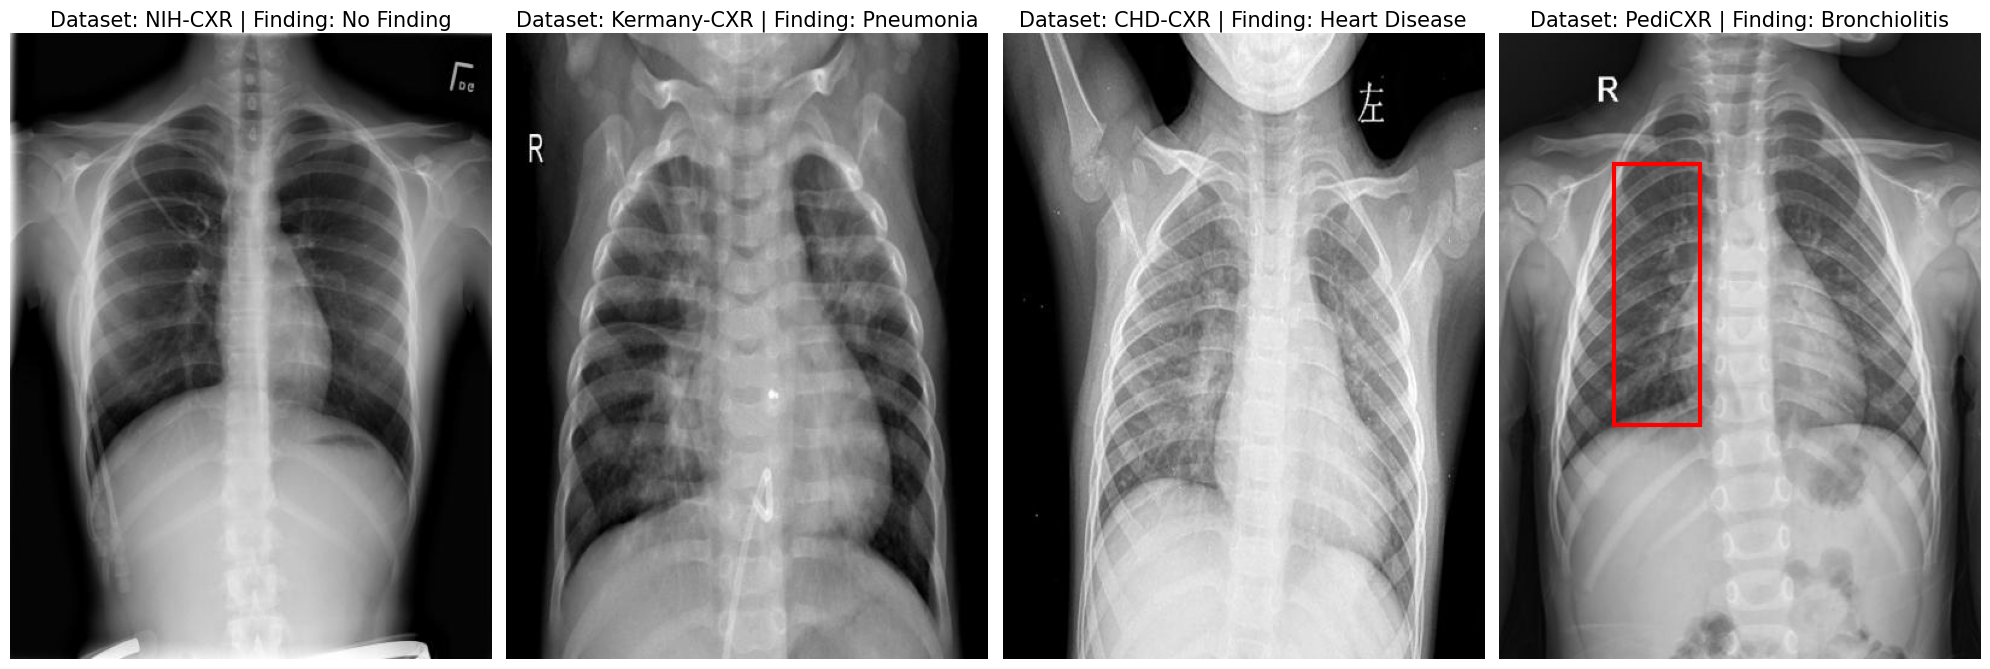

In [36]:
# data visualization figure #

# get a data row with no finding
mask = df['label'] == 'no finding'
no_finding_row = df[mask].iloc[0]
# get a data row with pneumonia
mask = df['label'] == 'pneumonia'
pneumonia_row = df[mask].iloc[50]
# get a data row with heart disease
mask = df['label'] == 'heart disease'
heart_disease_row = df[mask].iloc[50]
# get a data row with bronchiolitis
mask = df['label'] == 'bronchiolitis'
bronchiolitis_row = df[mask].iloc[50]

rows = [
    no_finding_row,
    pneumonia_row,
    heart_disease_row,
    bronchiolitis_row
]

original_dataset = [
    'NIH-CXR',
    'Kermany-CXR',
    'CHD-CXR',
    'PediCXR'
]

fig, axs = plt.subplots(1, 4, figsize=(20, 10))
for i, row in enumerate(rows):
    # plot image
    img_path = join(IMAGE_PATH, row['filename'])
    img = Image.open(img_path)
    axs[i].imshow(img, cmap='gray')
    # plot bbox if exists
    if row['has bbox']:
        min_x = row['min_x']
        min_y = row['min_y']
        width = row['width']
        height = row['height']
        rect = plt.Rectangle((min_x, min_y), width, height, edgecolor='red', facecolor='none', linewidth=3)
        axs[i].add_patch(rect)
    axs[i].set_title(f"Dataset: {original_dataset[i]} | Finding: {row['label'].title()}", fontsize=15)
    axs[i].axis('off')
plt.tight_layout()
plt.show()